In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = r"C:\Users\manan lad\Desktop\datascience\CNN\Cat vs Dog Using Transfer Learning\PetImages"

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(160,160),
    batch_size=32,
    color_mode="rgb"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(160,160),
    batch_size=32,
    color_mode="rgb"
)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [4]:
train_size = 20000   # approx after split
val_size = 5000

batch_size = 32

steps_per_epoch = train_size // batch_size
validation_steps = val_size // batch_size

In [5]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [7]:
inputs = keras.Input(shape=(160,160,3))

x = data_aug(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps
)

Epoch 1/5
619/625 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - accuracy: 0.9411 - loss: 0.1524

C:\Users\manan lad\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


625/625 ━━━━━━━━━━━━━━━━━━━━ 317s 500ms/step - accuracy: 0.9412 - loss: 0.1522 - val_accuracy: 0.9833 - val_loss: 0.0441
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 500ms/step - accuracy: 0.9635 - loss: 0.0907 - val_accuracy: 0.9853 - val_loss: 0.0403
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 488ms/step - accuracy: 0.9640 - loss: 0.0921 - val_accuracy: 0.9847 - val_loss: 0.0401
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 298s 477ms/step - accuracy: 0.9691 - loss: 0.0747 - val_accuracy: 0.9851 - val_loss: 0.0400
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 307s 491ms/step - accuracy: 0.9697 - loss: 0.0781 - val_accuracy: 0.9849 - val_loss: 0.0425


In [14]:
model.evaluate(val_ds, steps=validation_steps)

156/156 ━━━━━━━━━━━━━━━━━━━━ 66s 416ms/step - accuracy: 0.9887 - loss: 0.0324


[0.040607891976833344, 0.9855043292045593]

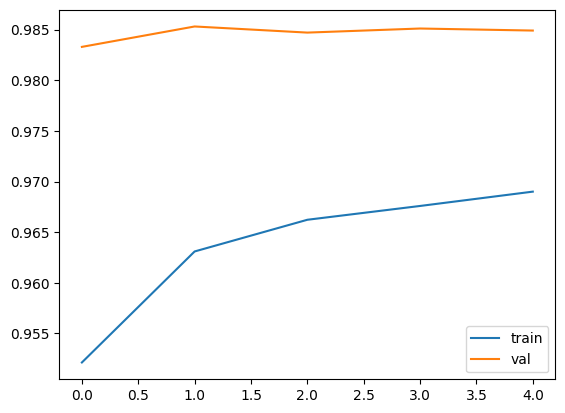

In [15]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()